Task 1: Data dimensionality, distance-based classifiers

1.1:

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA   
import umap
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [66]:
test_in = np.genfromtxt('data/test_in - Copy.csv', delimiter=',')
test_out = np.genfromtxt('data/test_out - Copy.csv', delimiter=',')
train_in = np.genfromtxt('data/train_in - Copy.csv', delimiter=',')
train_out = np.genfromtxt('data/train_out - Copy.csv', delimiter=',')

In [67]:
print(test_in.shape)
print(test_out.shape)

(1000, 256)
(1000,)


In [68]:
means = np.empty((10, 256))

for i in range(10):
    digit_mask = train_out == i
    means[i] = np.mean(train_in[digit_mask], axis=0)


In [69]:
min_dist = np.inf
max_dist = 0
for i in range(10):
    for j in range(i+1, 10):
        dist = np.sqrt(np.sum((means[i] - means[j])**2))
        # print(f"{i}, {j}: {dist}")
        if dist < min_dist:
            min_dist = dist
            min_pair = i, j
        if dist > max_dist:
            max_dist = dist
            max_pair = i, j
    
print(f"Most similar digits: {min_pair}, distance: {min_dist}")
print(f"Most different digits: {max_pair}, distance: {max_dist}")

Most similar digits: (7, 9), distance: 5.426474119055888
Most different digits: (0, 1), distance: 14.44960796590658


1.2:

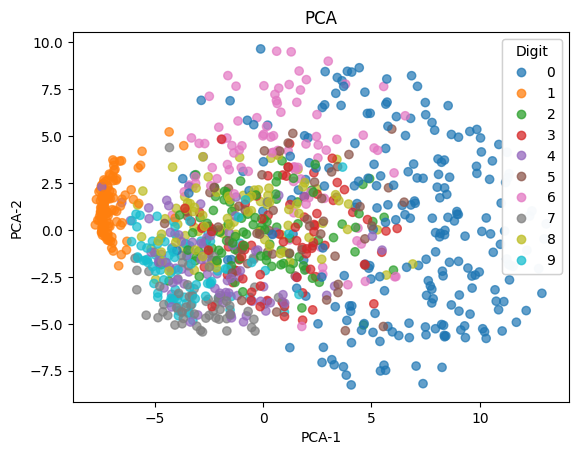

In [70]:
test_in_pca = PCA(n_components=2).fit_transform(test_in).T

scatter = plt.scatter(test_in_pca[0], test_in_pca[1], c=test_out, cmap='tab10', alpha=0.7)

legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)

plt.gca().add_artist(legend)

plt.title("PCA")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.show()

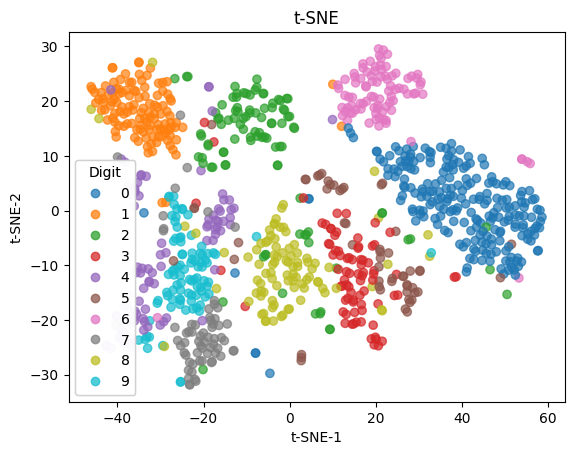

In [71]:
embedding_2d = TSNE(n_components=2).fit_transform(test_in).T
scatter = plt.scatter(embedding_2d[0], embedding_2d[1], c=test_out, cmap='tab10', alpha=0.7)

legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)

plt.gca().add_artist(legend)

plt.title("t-SNE")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.show()

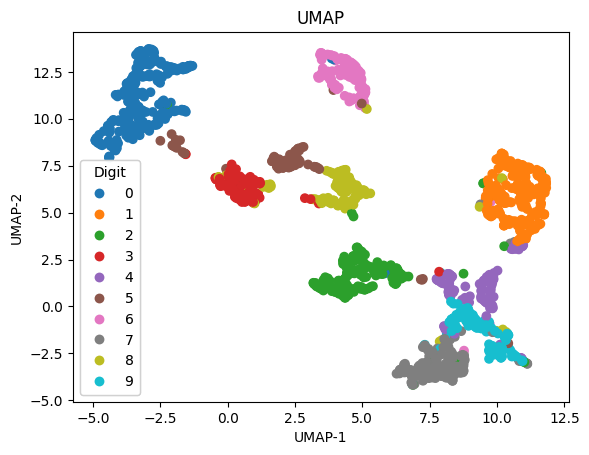

In [72]:
embedding_2d  = umap.UMAP(n_neighbors=5, min_dist=0.1).fit_transform(train_in).T
scatter = plt.scatter(embedding_2d[0], embedding_2d[1], c=train_out, cmap='tab10')

legend = plt.legend(
    *scatter.legend_elements(),
    title="Digit"
)

plt.gca().add_artist(legend)

plt.title("UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [73]:
min_distances = np.empty(len(train_in))
labels = np.empty(len(train_in))

for i in range(10):
    distances = np.sum((train_in - means[i])**2, axis=1)
    if i == 0:
        min_distances = distances
        labels = np.zeros(len(train_in))
    else:
        mask = distances < min_distances
        labels[mask] = i
        min_distances[mask] = distances[mask]

print(np.sum(labels == train_out) / len(train_out))

min_distances = np.empty(len(test_in))
labels = np.empty(len(test_in))

for i in range(10):
    distances = np.sum((test_in - means[i])**2, axis=1)
    if i == 0:
        min_distances = distances
        labels = np.zeros(len(test_in))
    else:
        mask = distances < min_distances
        labels[mask] = i
        min_distances[mask] = distances[mask]

print(np.sum(labels == test_out) / len(test_out))

0.8635032220269478
0.804


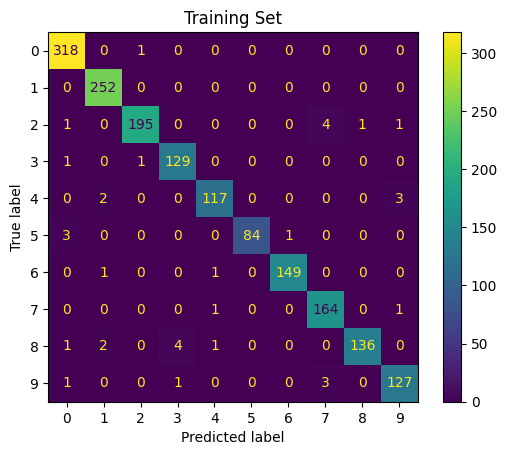

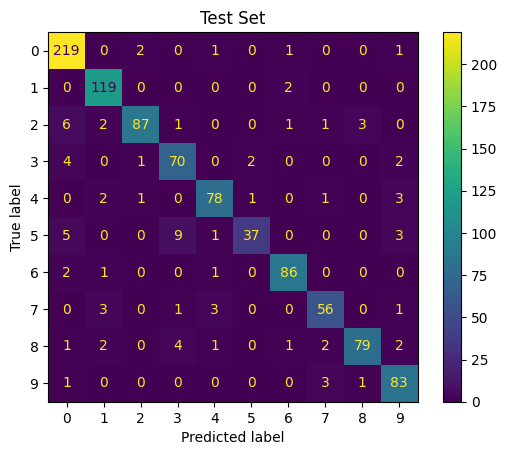

In [96]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(train_in, train_out)
labels_pred_train = neigh.predict(train_in)
labels_pred_test = neigh.predict(test_in)

ConfusionMatrixDisplay(confusion_matrix(train_out, labels_pred_train)).plot()
plt.title("Training Set")
plt.show()

ConfusionMatrixDisplay(confusion_matrix(test_out, labels_pred_test)).plot()
plt.title("Test Set")
plt.show()